# ♟️ What Decides a Chess Game? — Lichess 19k Games Analysis

A compact end-to-end analytics project: **audit → clean → engineer features → answer questions → model → conclude.**

**Dataset:** `games.csv` — one row per online chess game (players, ratings, time control, opening, result, full move list).

**Questions I want to answer**
1. Does playing White really give an edge — and does it depend on skill level or game speed?
2. How much does the rating gap between players actually predict the winner?
3. How do games end (checkmate, resignation, timeout, draw) across time controls and rated vs casual play?
4. Do some openings over- or under-perform *after* accounting for player strength?
5. How long do games last, and what shapes that?
6. Can a simple model predict the winner from **pre-game information only** — and which features matter?

**To run:** put `games.csv` next to this notebook.
`pip install pandas numpy matplotlib seaborn scipy scikit-learn`

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest
from scipy.optimize import minimize_scalar

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
COL = {"white": "#c9d1dc", "black": "#2b2f36", "draw": "#e0a458", "accent": "#5b7c99"}
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

## 1 · Data audit
Before analysing anything, check whether the data can be trusted. Each check below either passes or leads to a specific cleaning decision.

In [2]:
raw = pd.read_csv("games.csv")
ts_cols = ["created_at", "last_move_at"]

n_dup_id        = raw.id.duplicated().sum()
n_dup_content   = raw.drop(columns=ts_cols).duplicated().sum()
zero_dur        = (raw.created_at == raw.last_move_at).mean()
draw_mismatch   = ((raw.winner == "draw") != (raw.victory_status == "draw")).sum()
turns_ok        = (raw.moves.str.split().str.len() == raw.turns).mean()
_tc             = raw.increment_code.str.extract(r"(\d+)\+(\d+)").astype(int)
est_raw         = _tc[0] * 60 + _tc[1] * 40            # Lichess "estimated duration" in seconds

audit = pd.DataFrame([
    ("Missing values",              f"{raw.isna().sum().sum()}",                                   "None needed"),
    ("Duplicate game IDs",          f"{n_dup_id:,} rows ({n_dup_id/len(raw):.1%})",                "Drop — keep first occurrence"),
    ("…are they true duplicates?",  f"{n_dup_content:,} identical once timestamps are ignored",    "Yes: same games re-crawled, safe to dedupe"),
    ("Start time == last move time", f"{zero_dur:.0%} of games",                                   "Don't use duration; use move count for length"),
    ("winner=draw but status≠draw", f"{draw_mismatch} rows",                                        "Trust `winner` (timeouts vs. insufficient material)"),
    ("`turns` == number of moves listed", f"{turns_ok:.0%}",                                        "`turns` counts half-moves (plies)"),
    ("Fastest time control",        f"≈{est_raw.min()/60:.1f} min est. — only {(est_raw < 480).sum()} Blitz, 0 Bullet games", "Lichess speed names don't fit; bin by estimated duration instead"),
], columns=["Check", "Finding", "Decision"])
audit

,Check,Finding,Decision
0,Missing values,0,None needed
1,Duplicate game IDs,945 rows (4.7%),Drop — keep first occurrence
2,…are they true duplicates?,945 identical once timestamps are ignored,"Yes: same games re-crawled, safe to dedupe"
3,Start time == last move time,43% of games,Don't use duration; use move count for length
4,winner=draw but status≠draw,44 rows,Trust `winner` (timeouts vs. insufficient mate...
5,`turns` == number of moves listed,100%,`turns` counts half-moves (plies)
6,Fastest time control,"≈7.7 min est. — only 4 Blitz, 0 Bullet games",Lichess speed names don't fit; bin by estimate...


## 2 · Cleaning & feature engineering
Derived columns used throughout:
- **`time_class`** — Lichess's estimated duration = *base minutes × 60 + 40 × increment seconds*. The audit showed this file has no real Bullet/Blitz, so I bin it into four groups that actually have data: **<10 min, 10–15 min, 15–25 min, 25+ min**.
- **`rating_diff`** = White rating − Black rating, **`avg_rating`** and a skill **`bracket`**.
- **`white_score`** = 1 (White wins), 0.5 (draw), 0 (Black wins) — the standard chess scoring.
- **`elo_expected`** — the score White *should* get under the Elo formula, used later as a benchmark.
- **`opening_family`** (e.g. "Sicilian Defense" from "Sicilian Defense: Najdorf Variation") and **`first_move`**.

In [3]:
df = raw.drop_duplicates("id").reset_index(drop=True)

df["played_at"]   = pd.to_datetime(df.created_at, unit="ms")
df["year"]        = df.played_at.dt.year
df["full_moves"]  = np.ceil(df.turns / 2).astype(int)
df["game_type"]   = df.rated.map({True: "Rated", False: "Casual"})

tc = df.increment_code.str.extract(r"(?P<base>\d+)\+(?P<inc>\d+)").astype(int)
df["est_secs"]    = tc.base * 60 + tc.inc * 40
df["time_class"]  = pd.cut(df.est_secs, [-1, 599, 899, 1499, np.inf],
                           labels=["<10 min", "10–15 min", "15–25 min", "25+ min"])

df["rating_diff"] = df.white_rating - df.black_rating
df["avg_rating"]  = (df.white_rating + df.black_rating) / 2
df["bracket"]     = pd.cut(df.avg_rating, [0, 1200, 1500, 1800, 2100, 3000], right=False,
                           labels=["<1200", "1200–1499", "1500–1799", "1800–2099", "2100+"])

df["white_score"]   = df.winner.map({"white": 1, "draw": 0.5, "black": 0})
df["elo_expected"]  = 1 / (1 + 10 ** (-df.rating_diff / 400))
df["opening_family"] = df.opening_name.str.split(r"[:|]").str[0].str.strip()
df["first_move"]    = df.moves.str.split().str[0]

decisive = df[df.winner != "draw"]          # used wherever a draw would blur the question
print(f"{len(raw):,} raw rows  →  {len(df):,} unique games  ({df.played_at.min():%b %Y} – {df.played_at.max():%b %Y})")
df[["id", "white_rating", "black_rating", "rating_diff", "time_class", "opening_family",
    "full_moves", "winner", "victory_status"]].head()

20,058 raw rows  →  19,113 unique games  (Aug 2013 – Sep 2017)


,id,white_rating,black_rating,rating_diff,time_class,opening_family,full_moves,winner,victory_status
0,TZJHLljE,1500,1191,309,15–25 min,Slav Defense,7,white,outoftime
1,l1NXvwaE,1322,1261,61,10–15 min,Nimzowitsch Defense,8,black,resign
2,mIICvQHh,1496,1500,-4,10–15 min,King's Pawn Game,31,white,mate
3,kWKvrqYL,1439,1454,-15,15–25 min,Queen's Pawn Game,31,white,mate
4,9tXo1AUZ,1523,1469,54,25+ min,Philidor Defense,48,white,mate


## 3 · Overview

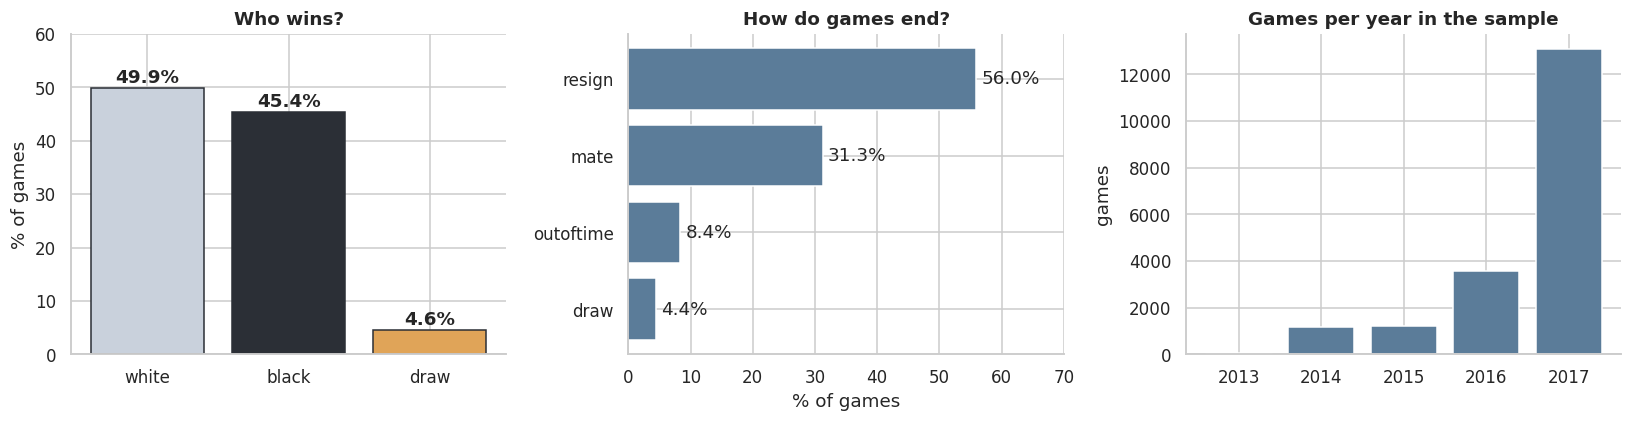

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

out = (df.winner.value_counts(normalize=True) * 100).reindex(["white", "black", "draw"])
ax[0].bar(out.index, out.values, color=[COL[k] for k in out.index], edgecolor=COL["black"])
for i, v in enumerate(out.values): ax[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
ax[0].set(title="Who wins?", ylabel="% of games", ylim=(0, 60))

vs = (df.victory_status.value_counts(normalize=True) * 100).sort_values()
ax[1].barh(vs.index, vs.values, color=COL["accent"])
for i, v in enumerate(vs.values): ax[1].text(v + .8, i, f"{v:.1f}%", va="center")
ax[1].set(title="How do games end?", xlabel="% of games", xlim=(0, 70))

yr = df.groupby("year").size()
ax[2].bar(yr.index.astype(str), yr.values, color=COL["accent"])
ax[2].set(title="Games per year in the sample", ylabel="games")

plt.tight_layout(); plt.show()

## 4 · Q1 — Is there a White advantage?
Draws don't tell us who is favoured, so I use **White's share of decisive games** (wins ÷ wins+losses) with 95 % Wilson confidence intervals. A fair game would sit at 50 %.

White wins 52.4% of decisive games (95% CI 51.6%–53.1%, n=18,225)


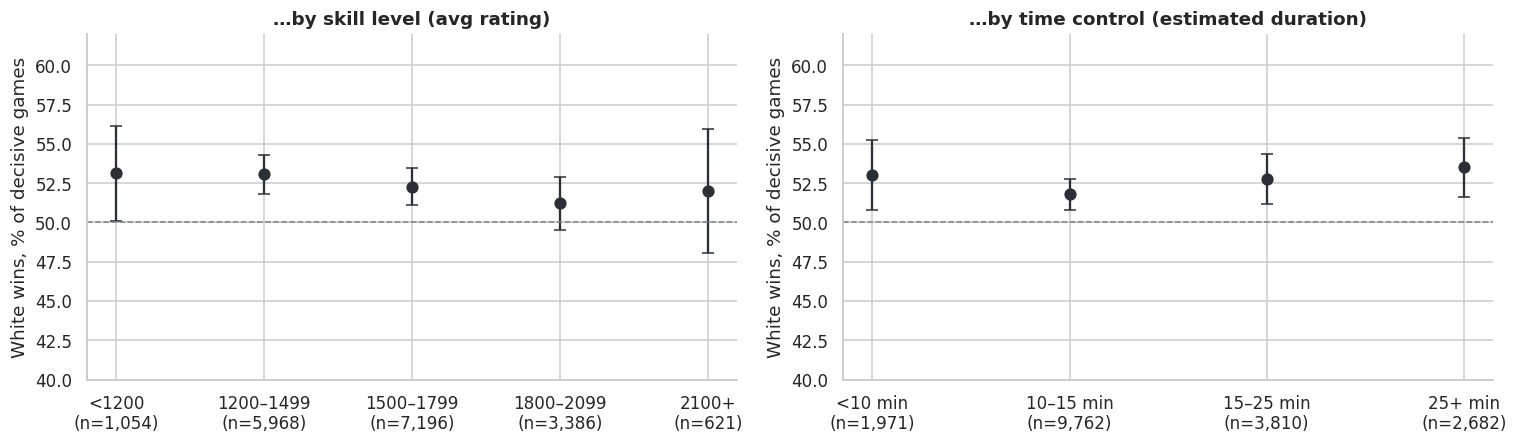

In [5]:
def white_edge(data, by=None):
    g = data.groupby(by, observed=True) if by else [("All games", data)]
    rows = []
    for name, d in g:
        k, n = int((d.winner == "white").sum()), len(d)
        ci = binomtest(k, n).proportion_ci(method="wilson")
        rows.append((name, n, k / n, ci.low, ci.high))
    return pd.DataFrame(rows, columns=["group", "n", "share", "lo", "hi"]).set_index("group")

overall = white_edge(decisive)
print(f"White wins {overall.share.iloc[0]:.1%} of decisive games "
      f"(95% CI {overall.lo.iloc[0]:.1%}–{overall.hi.iloc[0]:.1%}, n={overall.n.iloc[0]:,})")

def edge_plot(ax, g, title):
    x = np.arange(len(g))
    ax.errorbar(x, g.share * 100, yerr=[(g.share - g.lo) * 100, (g.hi - g.share) * 100],
                fmt="o", color=COL["black"], capsize=4, ms=7)
    ax.axhline(50, ls="--", color="grey", lw=1)
    ax.set_xticks(x, [f"{i}\n(n={n:,})" for i, n in zip(g.index, g.n)])
    ax.set(title=title, ylabel="White wins, % of decisive games", ylim=(40, 62))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
edge_plot(ax[0], white_edge(decisive, "bracket"),    "…by skill level (avg rating)")
edge_plot(ax[1], white_edge(decisive, "time_class"), "…by time control (estimated duration)")
plt.tight_layout(); plt.show()

## 5 · Q2 — How much does the rating gap matter?
Elo ratings are *built* to predict results: a player 400 points higher should score ~91 %. I test how well that holds by binning games on `rating_diff` and comparing **observed** White score with the **textbook Elo curve**.

Then I fit a two-parameter version of the curve by minimising log-loss:

> P(White score) = 1 / (1 + 10^(−(**k**·gap + **c**)/400))

- **c / k** = the *White bonus*, in rating points
- **k** = how steeply ratings translate into results (k = 1 is textbook Elo; k < 1 means upsets are more common than Elo predicts)

Steepness k = 0.64  (95% bootstrap CI 0.61–0.67)  →  a 100-point gap here behaves like a ~64-point gap in the textbook Elo formula
White bonus ≈ 22 rating points  (95% bootstrap CI 13–30)


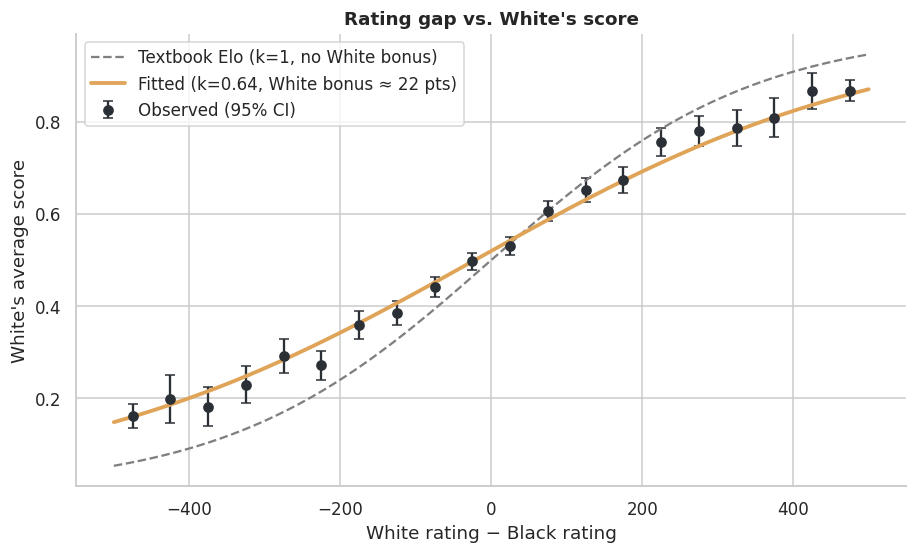

,Higher-rated player wins,games
Gap ≥ 0,65.2%,18225
Gap ≥ 100,73.9%,10007
Gap ≥ 200,80.3%,5800
Gap ≥ 400,86.1%,1953


In [6]:
# Observed score by rating-gap bin
edges = np.arange(-500, 501, 50)
cal = (df.assign(bin=pd.cut(df.rating_diff.clip(-499, 499), edges))
         .groupby("bin", observed=True).white_score.agg(["mean", "std", "size"]))
cal["mid"] = [iv.mid for iv in cal.index]
cal["se"]  = cal["std"] / np.sqrt(cal["size"])

# Fit the two-parameter curve (White bonus c, steepness k) by minimising log-loss
from scipy.optimize import minimize
rd, sc = df.rating_diff.to_numpy(float), df.white_score.to_numpy()

def fit_curve(rd, sc):
    def ll(theta):
        c, k = theta
        p = np.clip(1 / (1 + 10 ** (-(k * rd + c) / 400)), 1e-9, 1 - 1e-9)
        return -(sc * np.log(p) + (1 - sc) * np.log(1 - p)).mean()
    return minimize(ll, x0=[15, 0.8], method="Nelder-Mead").x

c_hat, k_hat = fit_curve(rd, sc)
rng = np.random.default_rng(42)
boot = np.array([fit_curve(rd[i], sc[i]) for i in (rng.integers(0, len(rd), len(rd)) for _ in range(200))])
k_lo, k_hi = np.percentile(boot[:, 1], [2.5, 97.5])
bonus_boot = boot[:, 0] / boot[:, 1]
white_bonus = c_hat / k_hat
b_lo, b_hi = np.percentile(bonus_boot, [2.5, 97.5])
print(f"Steepness k = {k_hat:.2f}  (95% bootstrap CI {k_lo:.2f}–{k_hi:.2f})  →  a 100-point gap here behaves like a ~{100*k_hat:.0f}-point gap in the textbook Elo formula")
print(f"White bonus ≈ {white_bonus:.0f} rating points  (95% bootstrap CI {b_lo:.0f}–{b_hi:.0f})")

# Fitted expectation per game (used again in the opening analysis as a fair benchmark)
df["elo_expected_adj"] = 1 / (1 + 10 ** (-(k_hat * df.rating_diff + c_hat) / 400))

xs = np.linspace(-500, 500, 200)
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.errorbar(cal.mid, cal["mean"], yerr=1.96 * cal.se, fmt="o", color=COL["black"], capsize=3, label="Observed (95% CI)")
ax.plot(xs, 1 / (1 + 10 ** (-xs / 400)), color="grey", ls="--", label="Textbook Elo (k=1, no White bonus)")
ax.plot(xs, 1 / (1 + 10 ** (-(k_hat * xs + c_hat) / 400)), color=COL["draw"], lw=2.5,
        label=f"Fitted (k={k_hat:.2f}, White bonus ≈ {white_bonus:.0f} pts)")
ax.set(title="Rating gap vs. White's score", xlabel="White rating − Black rating", ylabel="White's average score")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()

# How often does the favourite win?
big = decisive.assign(fav_won=lambda d: (d.rating_diff > 0) == (d.winner == "white"))
fav = pd.Series({f"Gap ≥ {t}": big[big.rating_diff.abs() >= t].fav_won.mean() for t in (0, 100, 200, 400)},
                name="Higher-rated player wins")
counts = pd.Series({f"Gap ≥ {t}": (big.rating_diff.abs() >= t).sum() for t in (0, 100, 200, 400)}, name="games")
pd.concat([fav.map("{:.1%}".format), counts], axis=1)

## 6 · Q3 — How do games end?

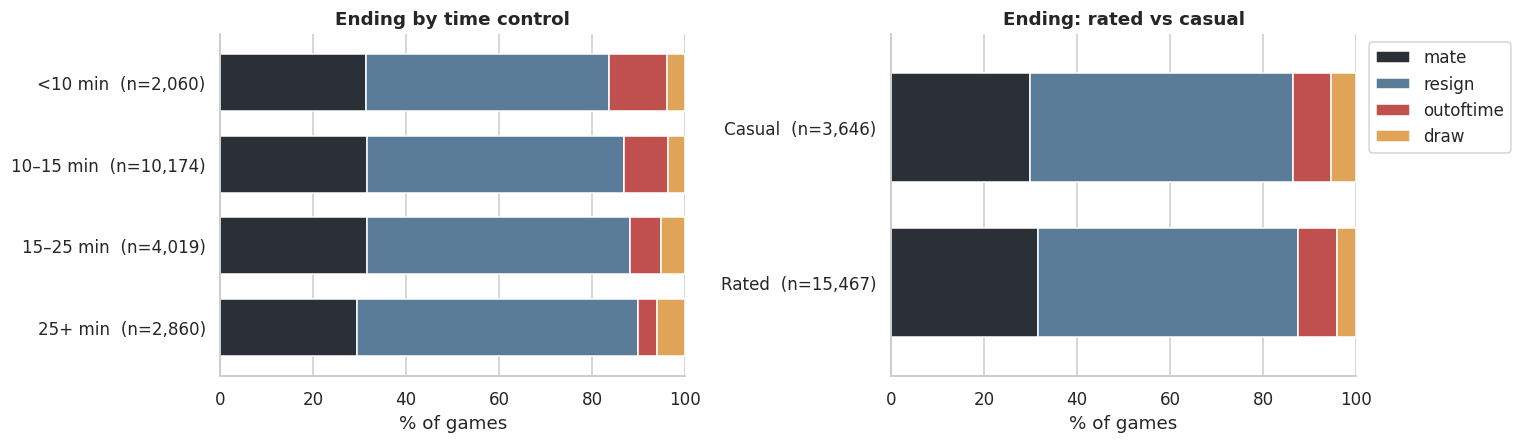

,games,median_moves,timeout_pct,draw_pct,avg_rating
time_class,,,,,
<10 min,2060,29.0,12.3,4.3,1640.5
10–15 min,10174,28.0,9.5,4.0,1597.4
15–25 min,4019,28.0,6.6,5.2,1588.7
25+ min,2860,26.0,4.0,6.2,1553.8


In [7]:
order  = ["mate", "resign", "outoftime", "draw"]
colors = ["#2b2f36", "#5b7c99", "#c0504d", "#e0a458"]

def ending_mix(by):
    ct = pd.crosstab(df[by], df.victory_status, normalize="index")[order] * 100
    n = df[by].value_counts()
    ct.index = [f"{i}  (n={n[i]:,})" for i in ct.index]
    return ct.iloc[::-1]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ending_mix("time_class").plot.barh(stacked=True, ax=ax[0], color=colors, width=.7, legend=False)
ending_mix("game_type").plot.barh(stacked=True, ax=ax[1], color=colors, width=.7)
ax[0].set(title="Ending by time control", xlabel="% of games", ylabel="")
ax[1].set(title="Ending: rated vs casual", xlabel="% of games", ylabel="")
ax[1].legend(title="", bbox_to_anchor=(1.01, 1), loc="upper left")
for a in ax: a.set_xlim(0, 100); a.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

(df.groupby("time_class", observed=True)
   .agg(games=("id", "size"), median_moves=("full_moves", "median"),
        timeout_pct=("victory_status", lambda s: (s == "outoftime").mean() * 100),
        draw_pct=("winner", lambda s: (s == "draw").mean() * 100),
        avg_rating=("avg_rating", "mean")).round(1))

In [8]:
(df.groupby("game_type")
   .agg(games=("id", "size"), median_moves=("full_moves", "median"),
        resign_pct=("victory_status", lambda s: (s == "resign").mean() * 100),
        timeout_pct=("victory_status", lambda s: (s == "outoftime").mean() * 100),
        draw_pct=("winner", lambda s: (s == "draw").mean() * 100),
        avg_rating=("avg_rating", "mean")).round(1))

,games,median_moves,resign_pct,timeout_pct,draw_pct,avg_rating
game_type,,,,,,
Casual,3646,25.0,56.4,8.1,5.6,1584.8
Rated,15467,29.0,55.8,8.4,4.4,1595.8


## 7 · Q4 — Do some openings over- or under-perform?
Raw opening win-rates are misleading: strong players favour certain openings, so an opening can look "good" just because its users are better. To control for that I compare each opening's actual White score to the score **expected from the rating gap alone, using the fitted curve from Q2 (which includes the White bonus and the flatter-than-Elo slope)**. A residual of +2 pts means White scored 2 points of win-percentage above what the ratings predicted.

I only test opening families with ≥ 200 games. With ~20 families tested, roughly one "significant" result is expected by chance alone — so treat outliers with caution.

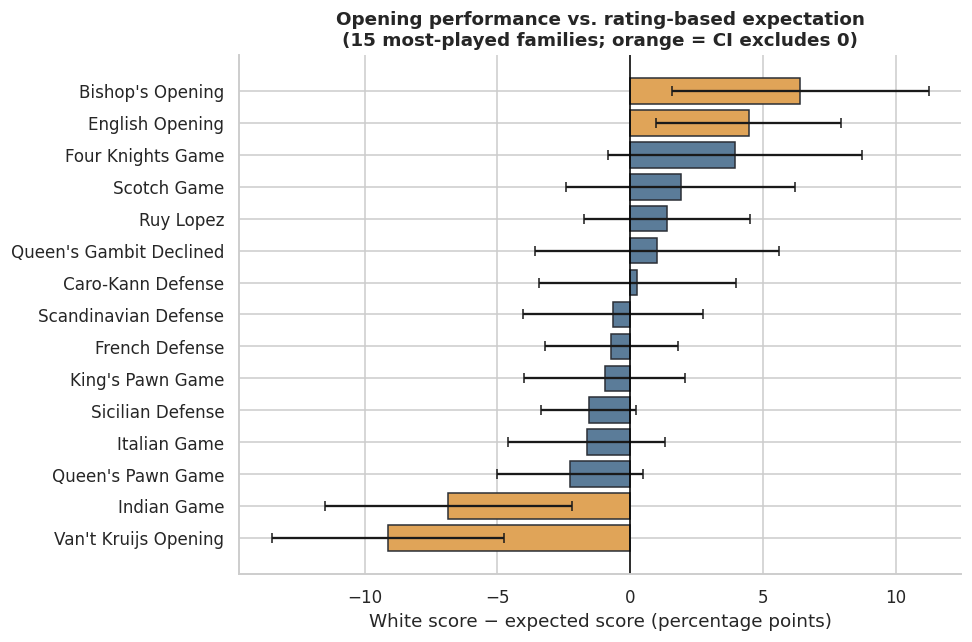

15 families plotted; CI excludes 0 for 4:  Van't Kruijs Opening (-9.1 pts, n=342);  Indian Game (-6.8 pts, n=312);  English Opening (+4.5 pts, n=699);  Bishop's Opening (+6.4 pts, n=310)
(At a 5% threshold, ~0.8 false positives are expected by chance alone.)


,games,share_of_games,avg_rating,white_score,resid
opening_family,,,,,
Sicilian Defense,2473,12.939,1674.202,0.480,-0.016
French Defense,1258,6.582,1628.213,0.515,-0.007
Queen's Pawn Game,1012,5.295,1596.140,0.493,-0.023
Italian Game,926,4.845,1587.681,0.515,-0.016
King's Pawn Game,871,4.557,1404.920,0.505,-0.010
Ruy Lopez,812,4.248,1634.036,0.550,0.014
English Opening,699,3.657,1625.988,0.572,0.045
Scandinavian Defense,688,3.600,1533.355,0.517,-0.006
Caro-Kann Defense,559,2.925,1666.939,0.520,0.003


In [9]:
df["resid"] = df.white_score - df.elo_expected_adj

fam = (df.groupby("opening_family")
         .agg(games=("id", "size"), avg_rating=("avg_rating", "mean"),
              white_score=("white_score", "mean"), resid=("resid", "mean"), resid_sd=("resid", "std"))
         .query("games >= 200").sort_values("games", ascending=False))
fam["share_of_games"] = fam.games / len(df) * 100
fam["ci95"] = 1.96 * fam.resid_sd / np.sqrt(fam.games)
fam["signif"] = (fam.resid.abs() > fam.ci95)

top = fam.head(15).sort_values("resid")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top.resid * 100, xerr=top.ci95 * 100, capsize=3,
        color=[COL["draw"] if s else COL["accent"] for s in top.signif], edgecolor=COL["black"])
ax.axvline(0, color="black", lw=1)
ax.set(title="Opening performance vs. rating-based expectation\n(15 most-played families; orange = CI excludes 0)",
       xlabel="White score − expected score (percentage points)")
plt.tight_layout(); plt.show()

flag = top[top.signif].sort_values("resid")
print(f"{len(top)} families plotted; CI excludes 0 for {len(flag)}:  " +
      ";  ".join(f"{n} ({r*100:+.1f} pts, n={g:,})" for n, r, g in zip(flag.index, flag.resid, flag.games)))
print(f"(At a 5% threshold, ~{0.05*len(top):.1f} false positives are expected by chance alone.)")

fam.head(10)[["games", "share_of_games", "avg_rating", "white_score", "resid"]].round(3)

In [10]:
# First move: 1.e4 vs 1.d4 vs the rest
fm = (df.groupby("first_move")
        .agg(games=("id", "size"), avg_rating=("avg_rating", "mean"),
             white_score=("white_score", "mean"), resid=("resid", "mean"))
        .query("games >= 100").sort_values("games", ascending=False))
fm["share_%"] = fm.games / len(df) * 100
fm.round(3)

,games,avg_rating,white_score,resid,share_%
first_move,,,,,
e4,11992,1580.654,0.528,0.004,62.743
d4,4363,1643.189,0.525,-0.005,22.827
c4,692,1620.665,0.558,0.036,3.621
Nf3,652,1666.016,0.557,0.016,3.411
e3,386,1398.179,0.368,-0.089,2.020
g3,168,1500.491,0.470,-0.044,0.879
b3,168,1627.271,0.491,0.014,0.879
f4,154,1587.104,0.474,-0.037,0.806
d3,128,1502.914,0.383,-0.024,0.670


## 8 · Q5 — How long do games last?
Length is measured in **full moves** (Lichess `turns` ÷ 2), since clock-based duration is unreliable in this file (see audit).

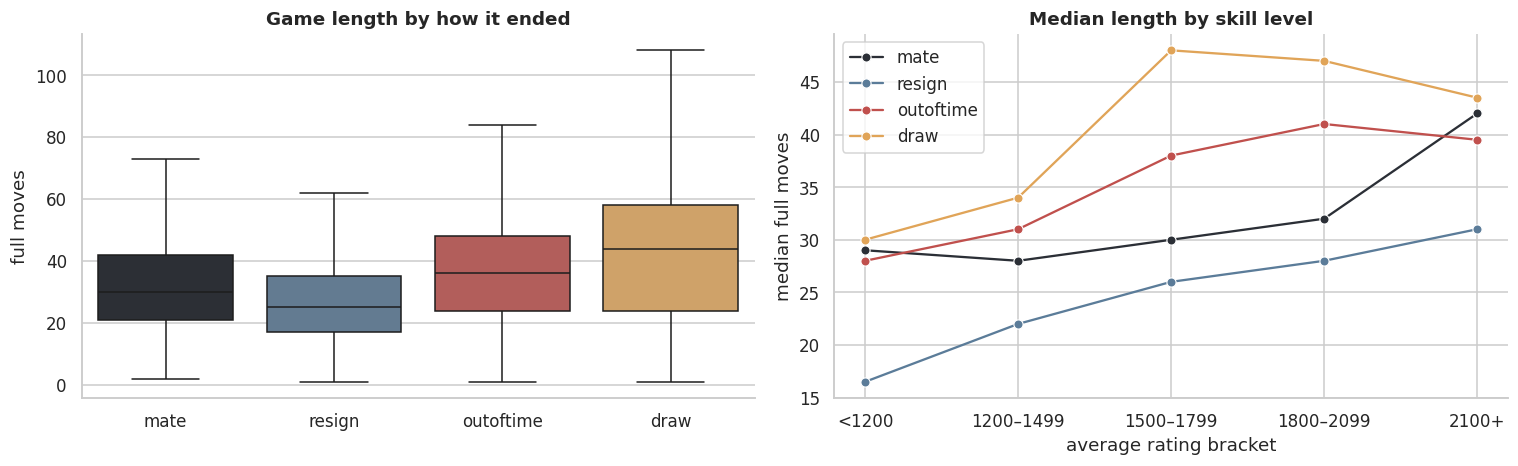

Games over in ≤10 full moves: 8.8%   (of those, 70% resignations, 9% timeouts)


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))

sns.boxplot(data=df, x="victory_status", y="full_moves", order=order, palette=colors,
            showfliers=False, ax=ax[0])
ax[0].set(title="Game length by how it ended", xlabel="", ylabel="full moves")

med = (df.groupby(["bracket", "victory_status"], observed=True).full_moves.median().reset_index())
sns.lineplot(data=med, x="bracket", y="full_moves", hue="victory_status", hue_order=order,
             palette=colors, marker="o", ax=ax[1])
ax[1].set(title="Median length by skill level", xlabel="average rating bracket", ylabel="median full moves")
ax[1].legend(title="")
plt.tight_layout(); plt.show()

short = (df.full_moves <= 10)
print(f"Games over in ≤10 full moves: {short.mean():.1%}   "
      f"(of those, {df[short].victory_status.eq('resign').mean():.0%} resignations, "
      f"{df[short].victory_status.eq('outoftime').mean():.0%} timeouts)")

## 9 · Q6 — Predicting the winner from pre-game information
**Task:** among decisive games, predict whether White wins.

**Leakage guard:** I only use information known *before the first move* — ratings, time control, rated/casual, first move and opening. `turns`, `moves`, `victory_status` and timestamps are excluded because they encode the outcome.

I compare five models with 5-fold stratified cross-validation to see what each extra layer of information buys.

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier

m = decisive.copy()
y = (m.winner == "white").astype(int)
m["log_secs"] = np.log1p(m.est_secs)
top_fam = m.opening_family.value_counts().head(25).index
m["opening_grp"] = m.opening_family.where(m.opening_family.isin(top_fam), "Other")
top_fm = m.first_move.value_counts().head(4).index
m["first_move_grp"] = m.first_move.where(m.first_move.isin(top_fm), "Other")

def prep(num, cat=()):
    parts = [("num", StandardScaler(), list(num))]
    if cat: parts.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), list(cat)))
    return ColumnTransformer(parts)

F_A = dict(num=["rating_diff"])
F_B = dict(num=["rating_diff", "avg_rating", "log_secs"], cat=["time_class", "game_type"])
F_C = dict(num=F_B["num"], cat=F_B["cat"] + ["opening_grp", "first_move_grp"])
cols = lambda f: f["num"] + f.get("cat", [])

experiments = [
    ("Baseline: always predict class prior", DummyClassifier(strategy="prior"),                                          F_A),
    ("LogReg: rating gap only",              make_pipeline(prep(**F_A), LogisticRegression()),                             F_A),
    ("LogReg: + skill level, speed, rated",  make_pipeline(prep(**F_B), LogisticRegression(max_iter=1000)),                F_B),
    ("LogReg: + opening & first move",       make_pipeline(prep(**F_C), LogisticRegression(max_iter=1000)),                F_C),
    ("Grad. boosting: all features",         make_pipeline(prep(**F_C), HistGradientBoostingClassifier(random_state=0)),   F_C),
]

cv = StratifiedKFold(5, shuffle=True, random_state=42)
rows = []
for name, model, f in experiments:
    r = cross_validate(model, m[cols(f)], y, cv=cv, scoring=["accuracy", "roc_auc", "neg_log_loss"])
    rows.append(dict(model=name, accuracy=r["test_accuracy"].mean(), acc_sd=r["test_accuracy"].std(),
                     roc_auc=r["test_roc_auc"].mean(), auc_sd=r["test_roc_auc"].std(), log_loss=-r["test_neg_log_loss"].mean()))
res = pd.DataFrame(rows).set_index("model")
res.round(4)

,accuracy,acc_sd,roc_auc,auc_sd,log_loss
model,,,,,
Baseline: always predict class prior,0.5237,0.0000,0.5000,0.0000,0.6920
LogReg: rating gap only,0.6514,0.0095,0.7177,0.0098,0.6152
"LogReg: + skill level, speed, rated",0.6520,0.0085,0.7172,0.0099,0.6155
LogReg: + opening & first move,0.6497,0.0072,0.7169,0.0093,0.6150
Grad. boosting: all features,0.6479,0.0084,0.7156,0.0101,0.6136


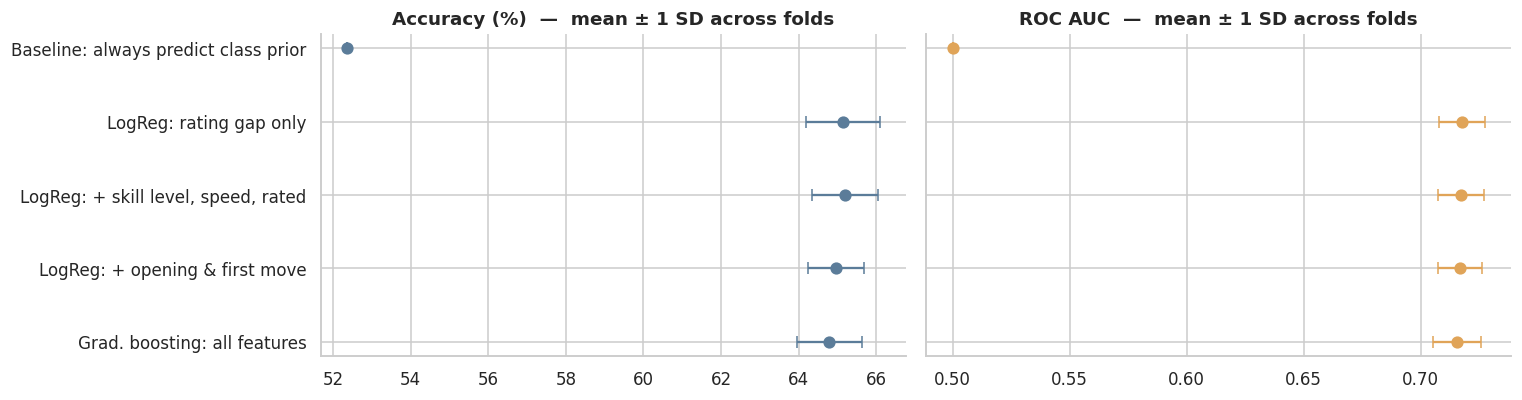

+100 rating points for White multiplies White's odds of winning by ×1.47
Implied White bonus from this model: ≈ 22 rating points (cf. 22 from the Elo-curve fit in Q2)


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True)
ypos = np.arange(len(res))[::-1]
ax[0].errorbar(res.accuracy * 100, ypos, xerr=res.acc_sd * 100, fmt="o", color=COL["accent"], capsize=4, ms=7)
ax[0].set(title="Accuracy (%)  —  mean ± 1 SD across folds")
ax[1].errorbar(res.roc_auc, ypos, xerr=res.auc_sd, fmt="o", color=COL["draw"], capsize=4, ms=7)
ax[1].set(title="ROC AUC  —  mean ± 1 SD across folds")
ax[0].set_yticks(ypos, res.index)
plt.tight_layout(); plt.show()

# Interpretable version: what does +100 rating points do to the odds of a White win?
lr = LogisticRegression().fit(m[["rating_diff"]] / 100, y)
odds = float(np.exp(lr.coef_[0][0]))
implied_shift = float(lr.intercept_[0] / lr.coef_[0][0] * 100)
print(f"+100 rating points for White multiplies White's odds of winning by ×{odds:.2f}")
print(f"Implied White bonus from this model: ≈ {implied_shift:.0f} rating points (cf. {white_bonus:.0f} from the Elo-curve fit in Q2)")

## 10 · Key findings

| # | Question | Finding |
|---|----------|---------|
| 1 | **White advantage?** | Yes, but small: White wins **52.4 %** of decisive games (95 % CI 51.6–53.1 %). It shows up at every skill level and time control (≈51–54 %); the intervals overlap, so there's no solid evidence that it changes with skill or speed. |
| 2 | **Rating gap** | The higher-rated player wins 65 % of decisive games, rising to 74 % (gap ≥ 100), 80 % (≥ 200) and 86 % (≥ 400). Playing White is worth **≈ 22 rating points** (CI 13–30) — confirmed by two independent methods. |
| 3 | **How games end** | Resignation ends 56 % of games, checkmate 31 %, timeout 8 %, draw 4 %. **Faster time controls → more timeouts** (12 % under 10 min vs 4 % at 25+ min); slower ones → more draws (4.3 % → 6.2 %). Rated and casual games end almost identically, except casual games have more draws (5.6 % vs 4.4 %) and are shorter (median 25 vs 29 moves). |
| 4 | **Openings** | After adjusting for player strength, most families land within ±2 points of expectation. 4 of 15 stand out (English Opening +4.5, Bishop's Opening +6.4, Indian Game −6.8, Van't Kruijs −9.1 pts) — but ~1 false positive is expected by chance. 1.e4 and 1.d4 make up 86 % of games; 1.e3 is the weakest first move here (−8.9 pts, n = 386). |
| 5 | **Game length** | Median game length: resignations 25 moves, checkmates 30, timeouts 36, draws 44. **Stronger players play longer games and resign later** — median resignation at move ~16 for <1200 vs ~31 for 2100+. |
| 6 | **Prediction** | Rating gap alone predicts the winner with **65 % accuracy / 0.72 AUC** (baseline 52 %). Adding time control, rated/casual, opening and first move — or switching to gradient boosting — adds **nothing** beyond fold-to-fold noise (±0.8 pts). |

### The most interesting result
**Ratings are less decisive than the Elo formula says.** The fitted steepness is *k* = 0.64 (CI 0.61–0.67): in this data, a 100-point rating gap behaves like a ~64-point gap in textbook Elo, so upsets are considerably more common than the formula predicts (see the Q2 chart). Plausible reasons — not tested here — include provisional/unstable ratings in a mixed player pool and the heavy 2017 sampling.

### What the project shows about method
- **Auditing changed the analysis.** Dedupe (4.7 % of rows), unusable duration data (43 % zero-length), and the discovery that the file has *no* Bullet/Blitz all forced design decisions before any charting.
- **Confidence intervals kept me honest.** Several apparent differences (White edge by skill, most opening effects) are indistinguishable from noise.
- **Benchmarking beat raw rates.** Comparing openings to a rating-based expectation removes the "strong players pick this opening" confound.
- **A simple model was the right model.** One feature carries essentially all the signal.

### Limitations
- The sample's selection process is unknown; ~68 % of games are from 2017 and there are no Bullet/Blitz games, so results may not generalise to all of Lichess.
- 15,635 unique players across 19k games — most appear once or twice, so player-level effects can't be modelled.
- The opening comparison is observational and involves many simultaneous tests; effects reflect *who plays* an opening as well as the opening itself.
- Draws are only ~4–5 % of games, so draw-specific conclusions are less certain.

### Ideas to extend this
1. Run **Stockfish** on the position after each opening's last book move and compare engine evaluation with the empirical results.
2. Build **features from the move list** (early queen moves, castling timing, first capture) and test whether they add anything beyond ratings.
3. Test whether the **k = 0.64 flattening** is stronger for low-rated or provisional-rating games.
4. Turn the notebook into a small **Streamlit dashboard** with filters for skill level and time control.